# Bayesian Kelly Betting 

This notebook simulates the plots described in the Bayesian Kelly betting article draft.

It generates:

1. **Fixed-fraction simulated paths with median wealth highlighted**
2. **Mean vs. median final wealth** after 300 rounds
3. **Online learning simulated paths with median wealth highlighted** 



Setup:
- Even-money binary bet
- True win probability: `theta = 0.6`
- 5,000 simulated wealth paths
- 300 betting rounds
- Initial wealth = 1
- Bayesian Kelly uses a neutral `Beta(1, 1)` prior


In [204]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


theta = 0.6
n_paths = 5000
n_rounds = 300
fractions = (0.1, 0.2, 0.4)
rounds = np.arange(n_rounds + 1)

# Background plotting controls
# The simulation still uses all 5,000 paths.
# Only a subset is drawn in the background to keep the plot readable.
max_background_paths = 100
background_alpha = 0.25
background_linewidth = 0.6
median_linewidth = 2.5


In [205]:
def simulate_fixed_fraction_paths(theta=0.6, fractions=(0.1, 0.2, 0.4), n_paths=5000, n_rounds=300, seed=42):
    """
    Simulate repeated even-money betting with fixed betting fractions.

    Wealth update:
        win:  W_{t+1} = W_t * (1 + f)
        loss: W_{t+1} = W_t * (1 - f)
    """
    rng = np.random.default_rng(seed)
    wins = rng.random((n_paths, n_rounds)) < theta

    wealth_paths = {}
    for f in fractions:
        multipliers = np.where(wins, 1 + f, 1 - f)
        wealth = np.concatenate(
            [np.ones((n_paths, 1)), np.cumprod(multipliers, axis=1)],
            axis=1
        )
        wealth_paths[f] = wealth

    return wealth_paths
           

In [206]:
fixed_paths = simulate_fixed_fraction_paths(
    theta=theta,
    fractions=fractions,
    n_paths=n_paths,
    n_rounds=n_rounds,
    seed=42
)


rng = np.random.default_rng(2026)
bg_idx = rng.choice(n_paths, size=max_background_paths, replace=False)


In [207]:
colors = ['#F0E442', '#0072B2', '#D55E00']  # Green, Blue, Red from the "Color Blind" palette

In [208]:
style = ['underbetting', 'kelly betting', 'overbetting']

## Figure 1: Fixed-fraction simulated paths with median highlighted

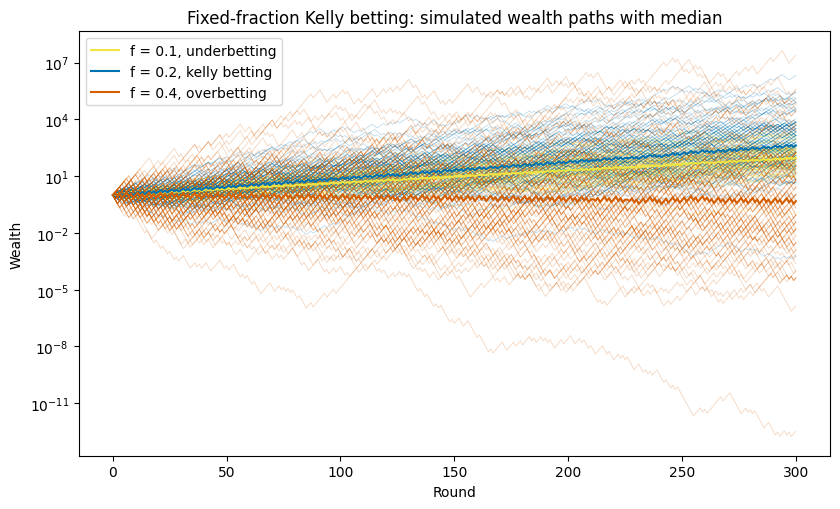

In [209]:
# Figure 1: Fixed-fraction simulated paths + median and mean wealth with 95% intervals
fig, ax = plt.subplots(figsize=(8.5, 5.2))

for f, wealth in fixed_paths.items():
    # Draw median first to get the default color, then draw light paths underneath
    median_line, = ax.plot(
        rounds,
        np.median(wealth, axis=0),
        color = colors[fractions.index(f)],
        alpha = 1,
        linewidth=1.5,
        linestyle='-',
        label=f"f = {f:.1f}, {style[fractions.index(f)]}",
        zorder=3
    )
    color = median_line.get_color()

    # Background paths
    ax.plot(
        rounds,
        wealth[bg_idx].T,
        color=color,
        alpha=background_alpha,
        linewidth=background_linewidth,
        zorder=1
    )

ax.set_yscale("log")
ax.set_xlabel("Round")
ax.set_ylabel("Wealth")
ax.set_title("Fixed-fraction Kelly betting: simulated wealth paths with median")
ax.legend()
fig.tight_layout()
plt.show()

## Figure 2: Mean vs. median final wealth

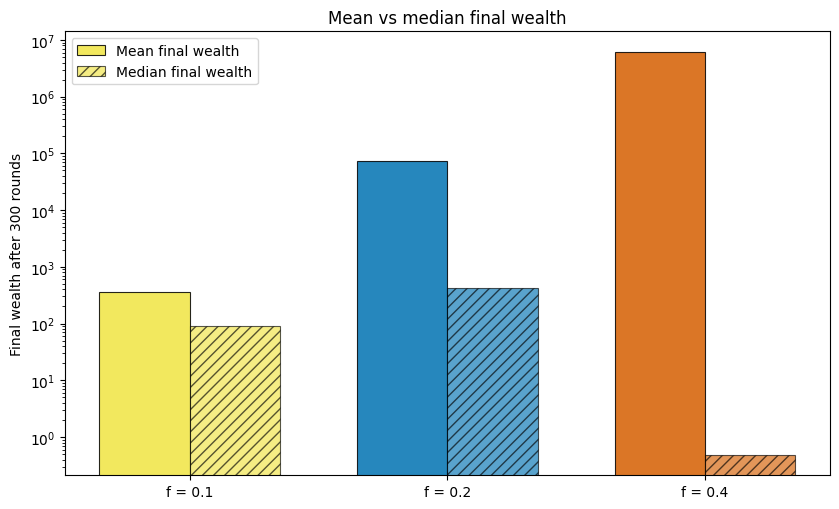

f = 0.1: mean final wealth = 365.01, median final wealth = 91.16
f = 0.2: mean final wealth = 74,149.30, median final wealth = 420.17
f = 0.4: mean final wealth = 6,249,041.12, median final wealth = 0.48


In [210]:
# Figure 2: Mean vs median final wealth
mean_final = [np.mean(fixed_paths[f][:, -1]) for f in fractions]
median_final = [np.median(fixed_paths[f][:, -1]) for f in fractions]

x = np.arange(len(fractions))
width = 0.35

fraction_colors = ['#F0E442', '#0072B2', '#D55E00']  # match Figure 1
median_hatches = ['///', '///', '///']

fig, ax = plt.subplots(figsize=(8.5, 5.2))
mean_bars = ax.bar(
    x - width / 2,
    mean_final,
    width,
    label="Mean final wealth",
    color=fraction_colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)
median_bars = ax.bar(
    x + width / 2,
    median_final,
    width,
    label="Median final wealth",
    color=fraction_colors,
    edgecolor="black",
    linewidth=0.8,
    hatch="///",
    alpha=0.65
)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"f = {f:.1f}" for f in fractions])
ax.set_ylabel("Final wealth after 300 rounds")
ax.set_title("Mean vs median final wealth")
ax.legend()
fig.tight_layout()
plt.show()

for f, mean_value, median_value in zip(fractions, mean_final, median_final):
    print(f"f = {f:.1f}: mean final wealth = {mean_value:,.2f}, median final wealth = {median_value:,.2f}")

## Figure 3: Online learning simulated paths with median highlighted

In [211]:
def simulate_online_kelly(theta=0.6, n_paths=5000, n_rounds=300, seed=42, bayesian=True, prior_a=1, prior_b=1):
    rng = np.random.default_rng(seed)
    wealth_paths = np.ones((n_paths, n_rounds + 1))

    for path in range(n_paths):
        wealth = 1.0
        wealth_history = [wealth]

        a = prior_a
        b = prior_b
        wins = 0
        total_bets = 0
        p_est = 0.5

        for round_num in range(n_rounds):
            if bayesian:
                p_est = a / (a + b)
            else:
                if total_bets > 0:
                    p_est = wins / total_bets

            f = max(0, 2 * p_est - 1)
            bet_win = rng.random() < theta

            if bet_win:
                wealth *= (1 + f)
                if bayesian:
                    a += 1
                else:
                    wins += 1
            else:
                wealth *= (1 - f)
                if bayesian:
                    b += 1

            total_bets += 1
            wealth_history.append(wealth)

        wealth_paths[path] = wealth_history

    return wealth_paths



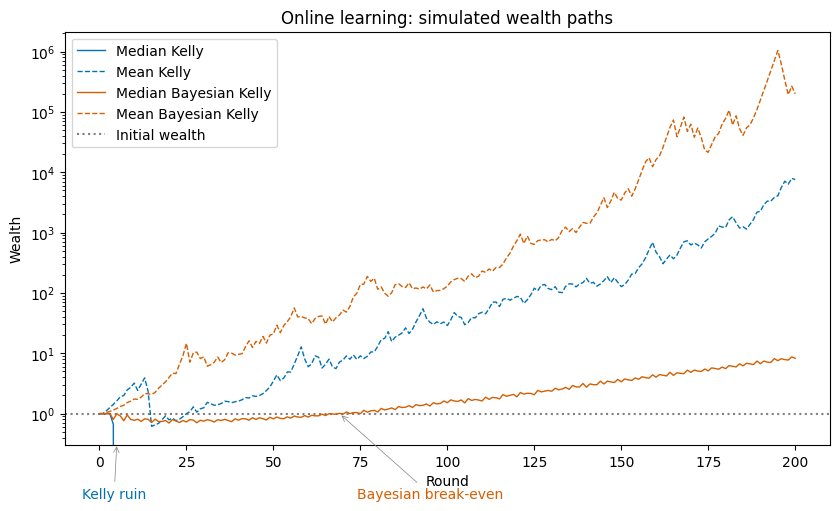

In [212]:
n_rounds = 200
rounds = np.arange(n_rounds + 1)

raw_online = simulate_online_kelly(theta=theta, n_paths=n_paths, n_rounds=n_rounds, seed=42, bayesian=False)
bayes_online = simulate_online_kelly(theta=theta, n_paths=n_paths, n_rounds=n_rounds, seed=42, bayesian=True)
# Figure 3: Online learning simulated paths with median highlighted
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Raw running Kelly median
median_raw = np.median(raw_online, axis=0)
mean_raw = np.mean(raw_online, axis=0)
ax.plot(
    rounds,
    median_raw,
    linewidth=1.0,
    label="Median Kelly",
    color = colors[1],
    zorder=3
)
ax.plot(
    rounds,
    mean_raw,
    linewidth=1.0,
    linestyle = '--',
    label="Mean Kelly",
    color = colors[1],
    zorder=3
)

# Bayesian Kelly median
median_bayes = np.median(bayes_online, axis=0)
mean_bayes = np.mean(bayes_online, axis=0)
ax.plot(
    rounds,
    median_bayes,
    linewidth=1.0,
    linestyle = '-',
    label="Median Bayesian Kelly",
    color = colors[2],
    zorder=3
)
ax.plot(
    rounds,
    mean_bayes,
    linewidth=1.0,
    linestyle = '--',
    label="Mean Bayesian Kelly",
    color = colors[2],
    zorder=3
)
ax.axhline(
    y=1.0,
    xmin=0,
    xmax=n_rounds,
    color='gray',
    linestyle=':',
    label="Initial wealth",
    zorder=2)

#kelly bankruptcy annotation
for i in range(len(median_raw)):
    if median_raw[i] == 0:
        bankruptcy_round = i
        break

ax.annotate(
    "Kelly ruin",
    xy=(bankruptcy_round, 0.32),
    xytext=(bankruptcy_round-10 , 0.04),
    arrowprops=dict(arrowstyle="->", lw=0.5, color="gray"),
    color=colors[1]
)

#Bayesian break even 
for i in range(len(median_bayes)):
    if median_bayes[i] > 1.0:
        break_even_round = i
        break
ax.annotate(
    "Bayesian break-even",
    xy=(break_even_round, 1.0),
    xytext=(break_even_round+5 , 0.04),
    arrowprops=dict(arrowstyle="->", lw=0.5, color="gray"),
    color=colors[2]
)


ax.set_yscale("log")
ax.set_xlabel("Round")
ax.set_ylabel("Wealth")
ax.set_title("Online learning: simulated wealth paths")
ax.legend()
fig.tight_layout()
plt.show()

## Notes

The exact simulated values are universal. They depend on the random seed and number of simulated paths.

The stable qualitative result is:

- Kelly betting grows strongly when the true edge is known.
- Overbetting can produce a huge mean final wealth while the typical path loses money.
- Raw online Kelly can be wrecked by early overconfidence.
- Bayesian Kelly regularizes early estimates and produces more stable typical wealth growth.

Only a subset of simulated paths is drawn in the background for readability, but all 5,000 paths are used to compute the mean and median values.
